<a href="https://colab.research.google.com/github/sayanndi/Breast-cancer-classification-with-NN/blob/main/Breast_Cancer_Classification_with_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [47]:
df = pd.read_csv('data.csv')

In [48]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [49]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [50]:
df = df.drop("Unnamed: 32", axis=1)

In [51]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [52]:
df.value_counts("diagnosis")

,count
diagnosis,
B,357
M,212


In [53]:
X = df.drop(["diagnosis", "id"], axis=1)
y = df["diagnosis"]

In [54]:
X.shape

(569, 30)

In [55]:
y

,diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [57]:
X.shape

(569, 30)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Standardtize the data

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Building the NN model**

In [60]:
# importing tensorflow and keras

import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

In [62]:
# setting up the layers of neural network
model = keras.Sequential([
    keras.Input(shape=(30,)), # Explicitly define input shape to match X_train
    keras.layers.Flatten(),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dense(2, activation='sigmoid')
])

In [63]:
# compiling the neural network

model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [64]:
# Training the Neural network

history = model.fit(X_train_scaled, y_train, validation_split = 0.1, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3423 - loss: 0.8602 - val_accuracy: 0.3696 - val_loss: 0.8761
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5892 - loss: 0.6645 - val_accuracy: 0.7174 - val_loss: 0.6643
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8509 - loss: 0.5042 - val_accuracy: 0.8478 - val_loss: 0.4957
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9218 - loss: 0.3808 - val_accuracy: 0.8478 - val_loss: 0.3743
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9438 - loss: 0.2935 - val_accuracy: 0.9348 - val_loss: 0.2951
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9462 - loss: 0.2355 - val_accuracy: 0.9348 - val_loss: 0.2458
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9535 - loss: 0.1974 - val_accuracy: 0.9348 - val_loss: 0.2142
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9584 - loss: 0.1715 - val_accuracy: 0.9348 - val_lo

Visualize accuracy and loss

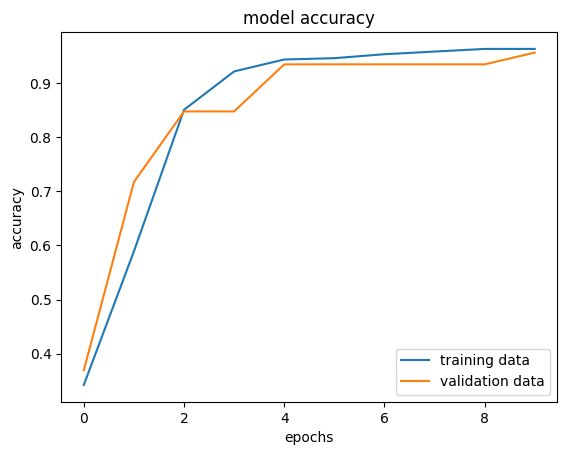

In [65]:
plt.plot(history.history["accuracy"]);
plt.plot(history.history["val_accuracy"]);

plt.title("model accuracy");
plt.ylabel("accuracy");
plt.xlabel("epochs");

plt.legend(['training data', 'validation data'], loc='lower right')

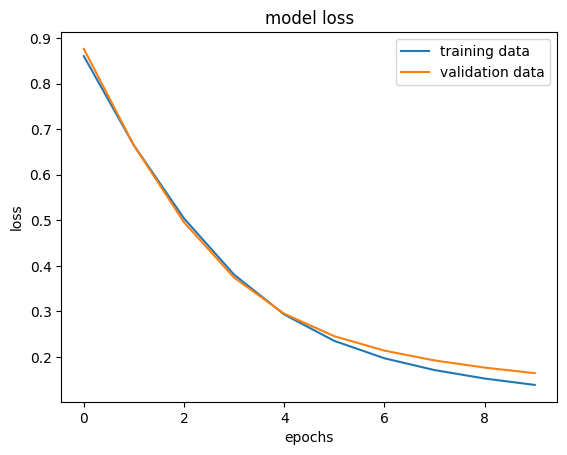

In [66]:
plt.plot(history.history["loss"]);
plt.plot(history.history["val_loss"]);

plt.title("model loss");
plt.ylabel("loss");
plt.xlabel("epochs");

plt.legend(['training data', 'validation data'], loc='upper right')

Accuracy of the model on test data

In [67]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9561 - loss: 0.1316
0.9561403393745422


In [68]:
print(X_test_scaled.shape)
print(X_test_scaled[0])

(114, 30)
[-0.46649743 -0.13728933 -0.44421138 -0.48646498  0.28085007  0.04160589
 -0.11146496 -0.26486866  0.41524141  0.13513744 -0.02091509 -0.29323907
 -0.17460869 -0.2072995  -0.01181432 -0.35108921 -0.1810535  -0.24238831
 -0.33731758 -0.0842133  -0.2632354  -0.14784208 -0.33154752 -0.35109337
  0.48001942 -0.09649594 -0.03583041 -0.19435087  0.17275669  0.20372995]


In [69]:
y_pred = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [70]:
print(y_pred.shape)
print(y_pred[0])

(114, 2)
[0.5846823  0.27782634]


In [71]:
# converting the prediction probability to class labels

y_pred_labels = [np.argmax(i) for i in y_pred]
print(y_pred_labels)

[np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0)

**Building the predictive system**

In [72]:
input_data= (17.99,	10.38,	122.8,	1001,	0.1184,	0.2776,	0.3001,	0.1471,	0.2419,	0.07871,	1.095,	0.9053,	8.589,	153.4,	0.006399,	0.04904,	0.05373,	0.01587,	0.03003,	0.006193,	25.38,	17.33,	184.6,	2019,	0.1622,	0.6656,	0.7119,	0.2654,	0.4601,	0.1189
)

input_data_as_numpy_array = np.asarray(input_data)

# Reshape to (1, 30) for a single sample with 30 features
input_data_reshaped = input_data_as_numpy_array.reshape(1, 30)

input_data_scaled = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_scaled)

print(prediction)

prediction_label = [np.argmax(prediction)]

print(prediction_label)

if prediction_label == 0:
  print("The tumor is benign")
else:
  print("The tumor is malignant")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[0.00402999 0.9137042 ]]
[np.int64(1)]
The tumor is malignant


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
